In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

#extra definitions 

def modelerr(base, title = '', additional_title = ''): 
    files = os.listdir(base)
    files = [f for f in files if '.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' not in f]
    print(len(full_files))
    p = Precision()
    err = p.mult_models(full_files)
    #print(len(err))
    plt.figure()
    plt.hist(err, bins = 50)

    if "StimRange0to45" in base:
        model_name = base.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
    else:
        model_name = base.split('workingmemory')[1].split('/')[1] 
    if 'decodedrew' in base:
        rewardfun = 'Decoded'
    else: 
        rewardfun = 'Unit Difference'
    if 'contexp' in base:
        rewardtype = 'Continuous Exponential'
    elif 'RewThresh' in base:
        rewardtype = 'Binary'
    else:
        rewardtype = 'Continuous Linear'
    if 'NoIgnore' in base:
        ignore = ', No Ignore Trials'
    else:
        ignore = ''
    if title == '':
        title = model_name + ', Reward Function: ' + rewardtype +', ' +rewardfun +' '+ ignore +' '+additional_title
    plt.title(title)
    abserr = np.mean(np.abs(err))
    legend = 'Average Absolute Error = {:.2f}'.format(abserr)
    #mse = np.sqrt(np.mean(err**2))
    #legend = 'mse = {:.2f}'.format(mse)
    plt.legend([legend])
    plt.show()
    
    return err


def overlayhist(base, base2, task,experiment, errchunk = [], err = [], title = '', savefig = False, savefile = '', ABE = False):

    
    if len(errchunk) == 0:
        base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
        files = os.listdir(base_chunk)
        files = [f for f in files if '.csv' in f]
        full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
        print(len(full_files))
        p = Precision()
        errchunk = p.mult_models(full_files)
        
        if ABE:
            total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
        else:
            total_mean_chunk, std_chunk = 0,0
    
    if len(err) == 0:
        if task == "2":
            base_nochunk = base + "sir2_new/"+base2+experiment
        else:
            base_nochunk = base+ "sir"+task+"/"+base2+experiment
        files = os.listdir(base_nochunk)
        files = [f for f in files if '.csv' in f]
        full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
        print(len(full_files))
        p = Precision()
        err = p.mult_models(full_files)
        if ABE:
            total_mean_nochunk, std_nochunk = geterror(base_nochunk, full_files)
        else:
            total_mean_nochunk, std_nochunk = 0,0

    plot1 = plt.hist(errchunk,bins = np.linspace(-180,180,45), alpha = 0.4)
    plot2 = plt.hist(err,bins = np.linspace(-180,180,45), alpha = 0.4, color = "yellow")

    # calc middle of bin and width of bin
    ax = [(plot1[1][x]+plot1[1][x+1])/2 for x in range(len(plot1[1])-1)] 
    diff = [_plot1 - _plot2 for _plot1, _plot2 in zip(plot1[0], plot2[0])]
    plt.bar(ax, diff,width = 6, color = "red")
    plt.legend(['Chunk', "No Chunk", "Chunk - No Chunk"])
    CB = chunkingbenefit(ax,diff,len(err))
    plt.title(title+" ,CB: {:.4f}".format(CB))
    if savefig: 
        plt.savefig(savefile)    
    plt.show()
    
    
    return errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk



def chunkingbenefit(ax, diff, numtrials):
    npax = np.array(ax)
    npdiff = np.array(diff)
    #density (in the diff histogram) in middle - density outside 
    CB = np.sum(npdiff[np.logical_and(npax<30,npax>-30)])-np.sum(npdiff[np.logical_or(npax>30, npax<-30)]) 
    CB_norm = CB/numtrials
    return CB_norm 


def geterror(base, full_files = []):
    if len(full_files) == 0:
        full_files = getfiles(base)
    num_models = len(full_files)
    p = Precision()
    L1_means = np.zeros(num_models)
    L1_vars = np.zeros(num_models)
    for f in range(len(full_files)):
        #import pdb; pdb.set_trace()
        err_model = p.mult_models([full_files[f]])
        L1 = np.abs(err_model)
        L1_means[f]=np.mean(L1)
        L1_vars[f] = np.var(L1)
    #mse = np.sqrt(np.mean(err**2)) 
    total_mean = np.mean(L1_means)
    total_var = np.mean(L1_vars)/num_models
    #err = p.mult_models(full_files)
    return total_mean, np.sqrt(total_var)

def run_all(base, base2, experiment):
    task = "4"
    errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

    task = "3"
    errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

    task = "2"
    errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


The mysir2 for trace.gate.nogoposlr is saved in defaultsG07 even though it is =0.1; 
For actual G07 file - will put it in G07real and then rename G07 as defaults and rename G07real as G07


decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo08/
80
80


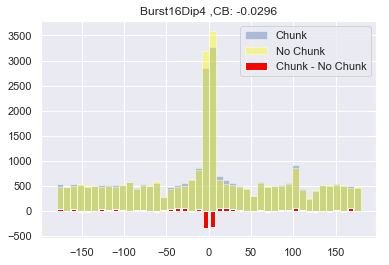

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo08/
80
80


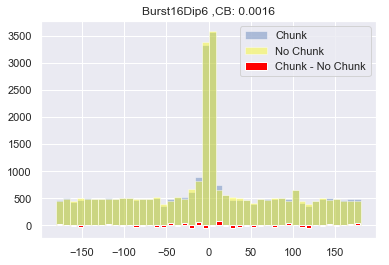

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo08/
80
80


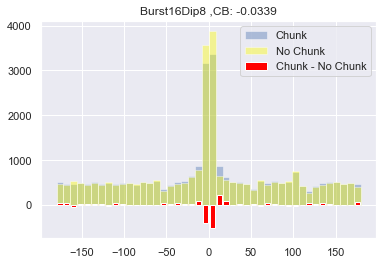

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo08/
80
80


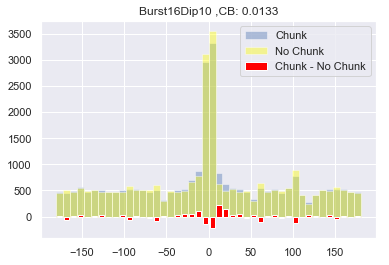

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo08/
80
80


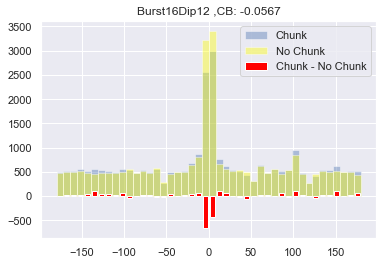

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo08/
80
80


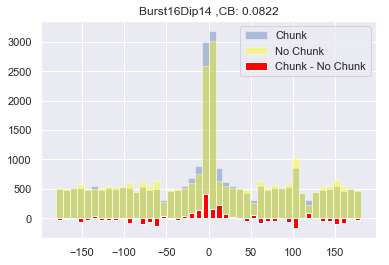

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo08/
80
80


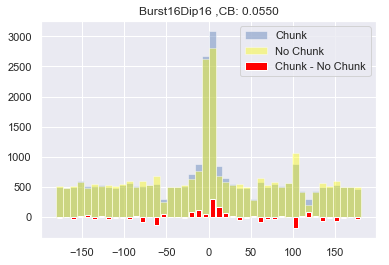

In [45]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]

## burst 0.4 - 1.0; then re-load those files before running burst 1.2-1.6
# Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
#Burst = [1.2, 1.4, 1.6]
# BurstName =["4", "6", "8", "10", "12", "14", "16"]
#BurstName = ["12", "14", "16"]
BurstName =["16"]
Burst = [1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "4"
nogo = "TestNoGo08/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo08"

# chunking_benefit=[]
# chunk_ABE = []
# nochunk_ABE = []
# burstdip = []
#chunking_benefit = np.load("sir"+task+"_chunking_benefit"+savefile_append+".npy")
#chunk_ABE = np.load("sir"+task+"_chunk_ABE"+savefile_append+".npy")
#nochunk_ABE = np.load("sir"+task+"_nochunk_ABE"+savefile_append+".npy")
#burstdip = np.load("sir"+task+"_burstdip"+savefile_append+".npy")

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

In [56]:
burstdip = list(np.load("sir"+task+"_burstdip"+savefile_append+".npy"))

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip4/TestNoGo125/
80
80


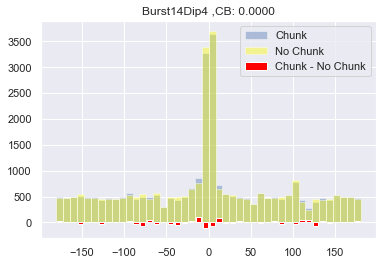

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/TestNoGo125/
80
80


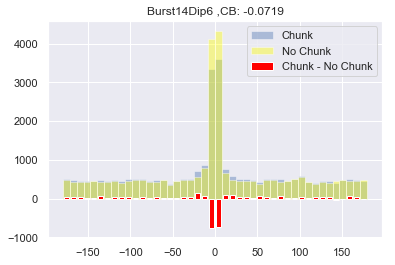

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip8/TestNoGo125/
80
80


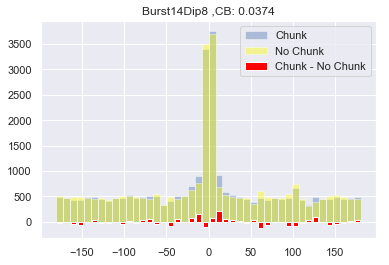

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/TestNoGo125/
80
80


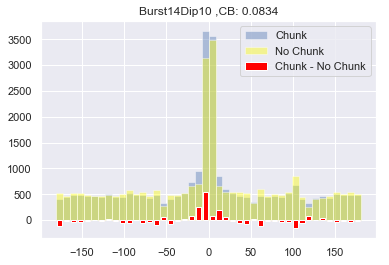

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip12/TestNoGo125/
80
80


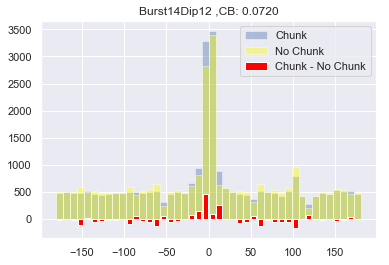

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip14/TestNoGo125/
80
80


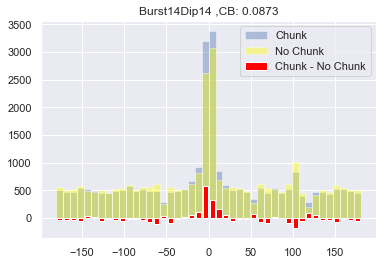

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip16/TestNoGo125/
80
80


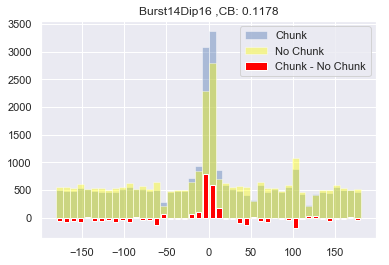

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo125/
80
80


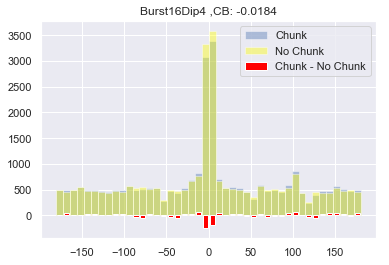

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo125/
80
80


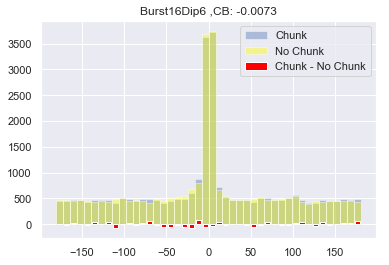

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo125/
80
80


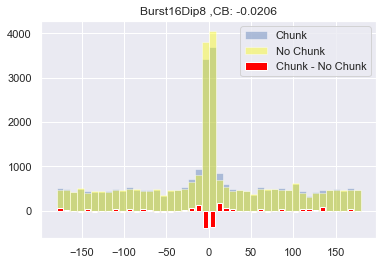

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo125/
80
80


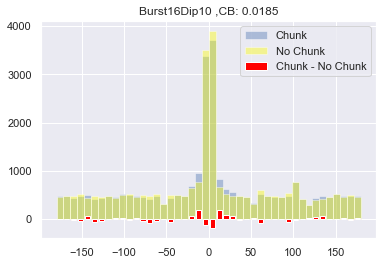

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo125/
80
80


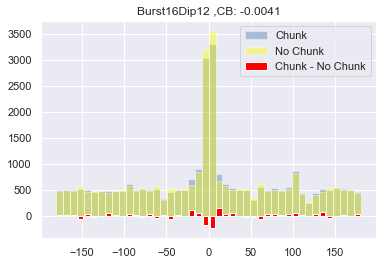

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo125/
80
80


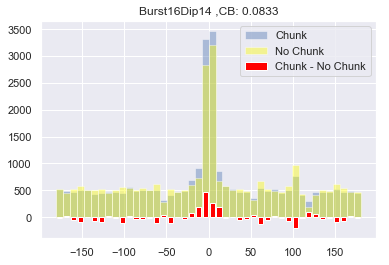

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo125/
80
80


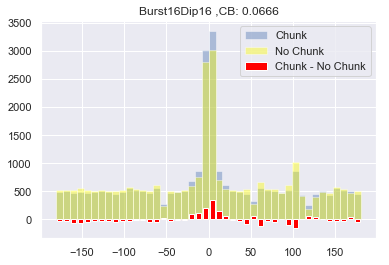

In [60]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]

# Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# BurstName =["4", "6", "8", "10", "12", "14", "16"]
# DipName = ["4", "6", "8", "10", "12", "14", "16"]

Burst = [1.4,1.6]
BurstName = ["14", "16"]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "4"
nogo = "TestNoGo125/"#"TestNoGo08/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo125"

# chunking_benefit=[]
# chunk_ABE = []
# nochunk_ABE = []
# burstdip = []
chunking_benefit = list(np.load("sir"+task+"_chunking_benefit"+savefile_append+".npy"))
chunk_ABE = list(np.load("sir"+task+"_chunk_ABE"+savefile_append+".npy"))
nochunk_ABE = list(np.load("sir"+task+"_nochunk_ABE"+savefile_append+".npy"))
burstdip = list(np.load("sir"+task+"_burstdip"+savefile_append+".npy"))

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip4/TestNoGo16/
80
80


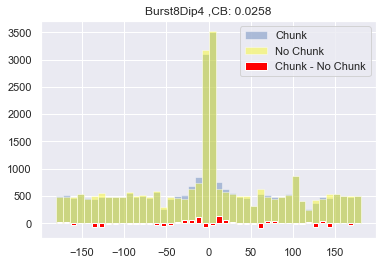

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip6/TestNoGo16/
80
80


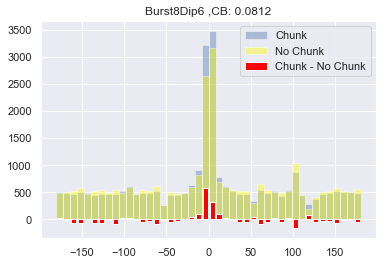

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip8/TestNoGo16/
80
80


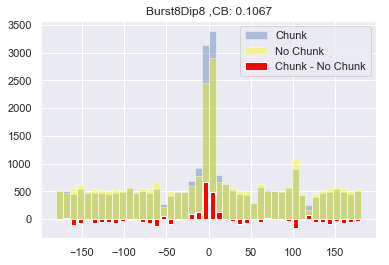

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip10/TestNoGo16/
80
80


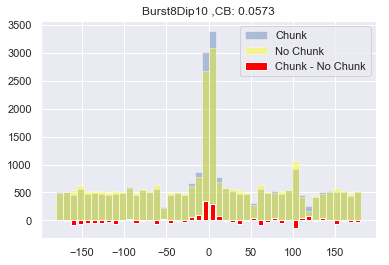

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip12/TestNoGo16/
80
80


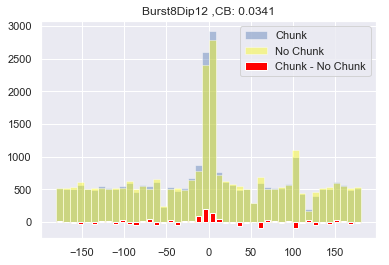

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip14/TestNoGo16/
80
80


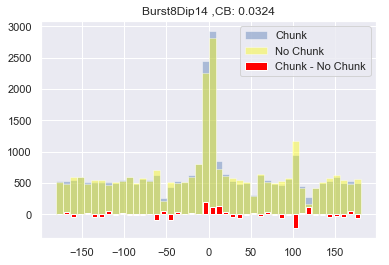

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip16/TestNoGo16/
80
80


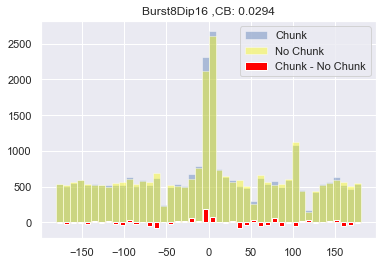

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip4/TestNoGo16/
80
80


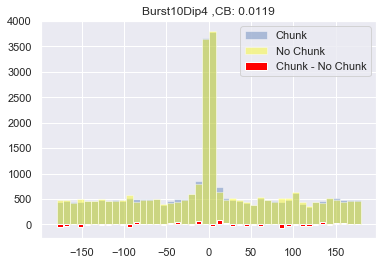

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/TestNoGo16/
80
80


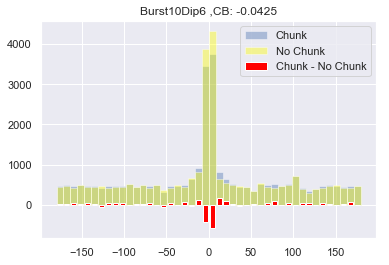

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip8/TestNoGo16/
80
80


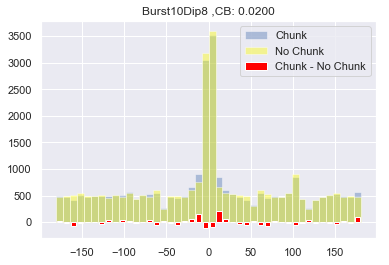

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo16/
80
80


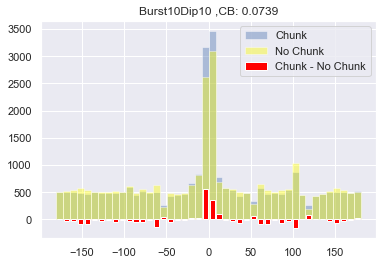

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip12/TestNoGo16/
80
80


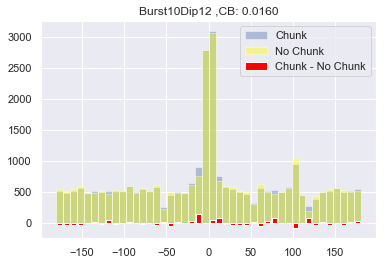

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip14/TestNoGo16/
80
80


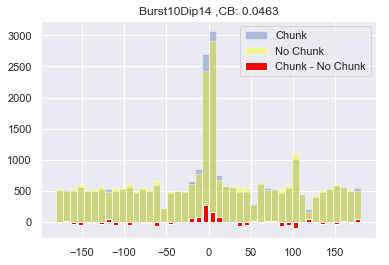

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/TestNoGo16/
80
80


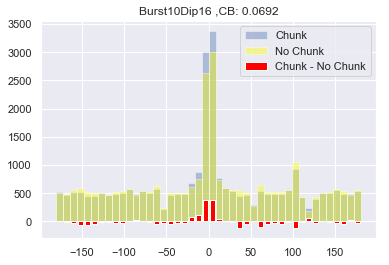

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip4/TestNoGo16/
80
80


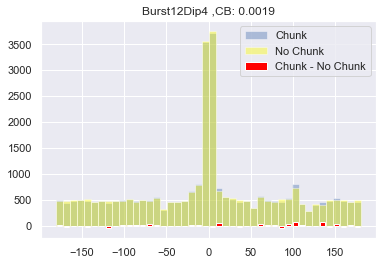

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo16/
80
80


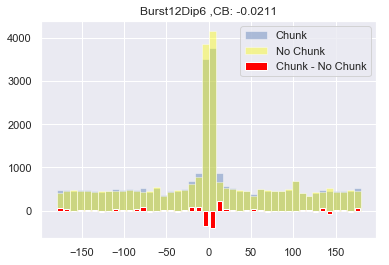

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo16/
80
80


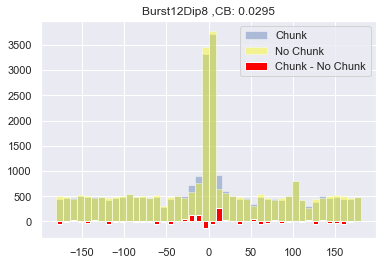

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip10/TestNoGo16/
80
80


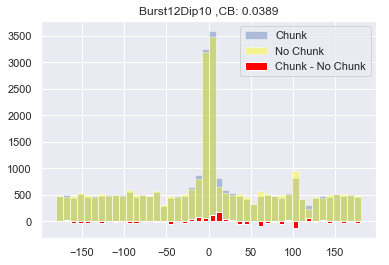

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip12/TestNoGo16/
80
80


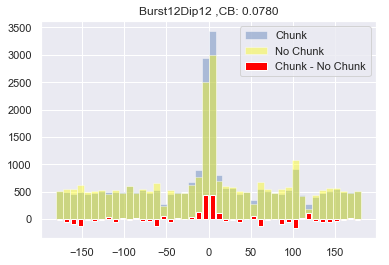

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip14/TestNoGo16/
80
80


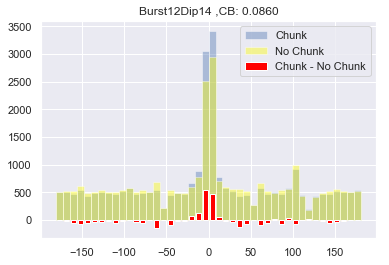

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip16/TestNoGo16/
80
80


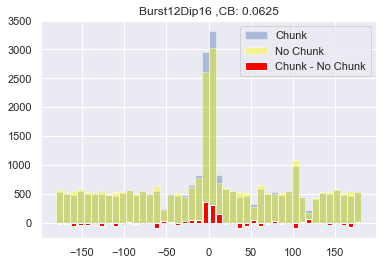

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip4/TestNoGo16/
80
80


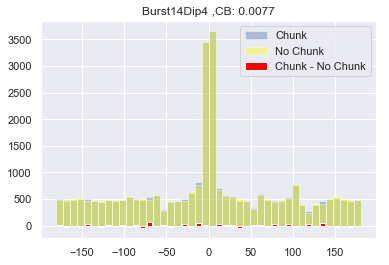

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/TestNoGo16/
80
80


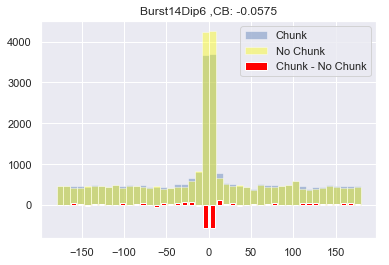

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip8/TestNoGo16/
80
80


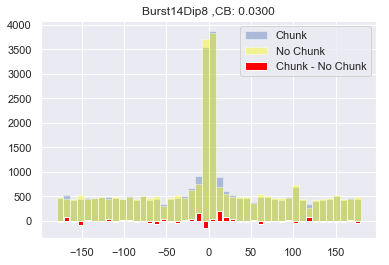

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/TestNoGo16/
80
80


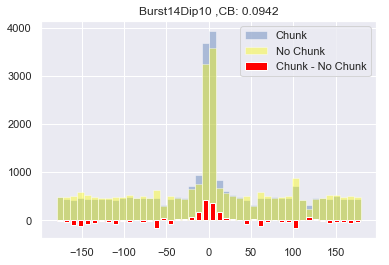

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip12/TestNoGo16/
80
80


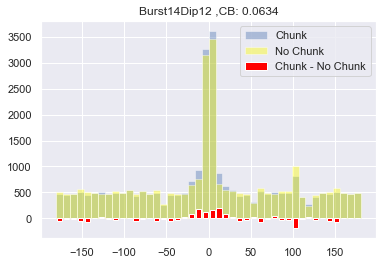

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip14/TestNoGo16/
80
80


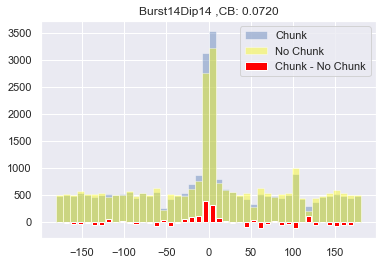

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip16/TestNoGo16/
80
80


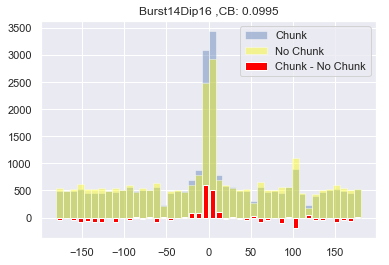

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo16/
80
80


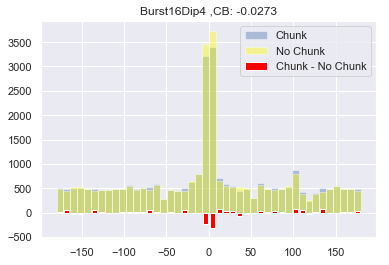

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo16/
80
80


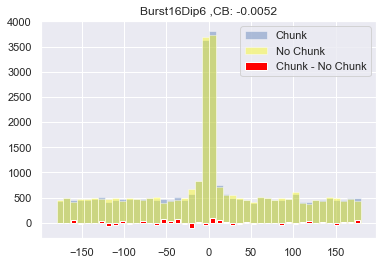

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo16/
80
80


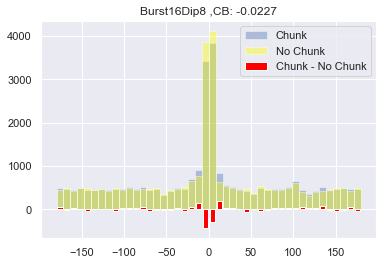

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo16/
80
80


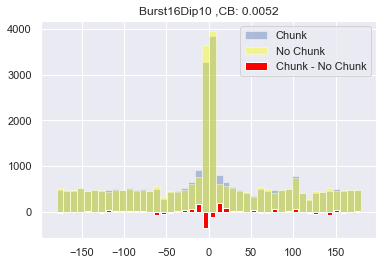

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo16/
80
80


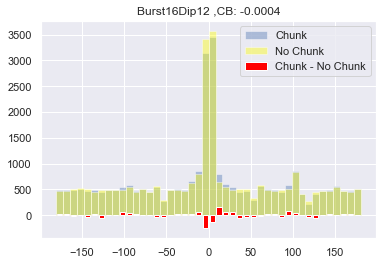

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo16/
80
80


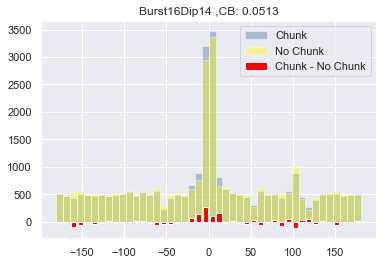

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo16/
80
80


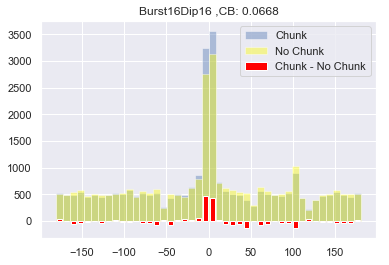

In [54]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]

Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["4", "6", "8", "10", "12", "14", "16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

Burst = [0.8, 1.0, 1.2, 1.4, 1.6]
BurstName = ["8", "10", "12", "14", "16"]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "4"
nogo = "TestNoGo16/"#"TestNoGo08/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo16"

# chunking_benefit=[]
# chunk_ABE = []
# nochunk_ABE = []
# burstdip = []
#chunking_benefit = np.load("sir"+task+"_chunking_benefit"+savefile_append+".npy")
#chunk_ABE = np.load("sir"+task+"_chunk_ABE"+savefile_append+".npy")
#nochunk_ABE = np.load("sir"+task+"_nochunk_ABE"+savefile_append+".npy")
#burstdip = np.load("sir"+task+"_burstdip"+savefile_append+".npy")

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

In [63]:
chunking_benefit = chunking_benefit[:-1]
nochunk_ABE = nochunk_ABE[:-1]
chunk_ABE = chunk_ABE[:-1]
burstdip = burstdip[:-1]

In [64]:
len(chunking_benefit)

28

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip4/TestNoGo08/
80
80


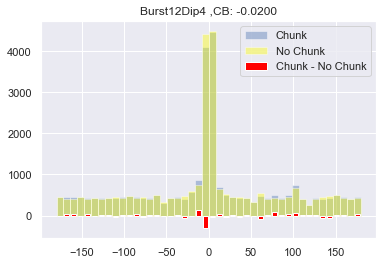

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo08/
80
80


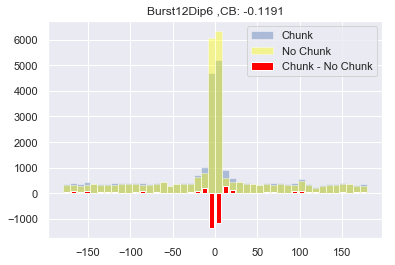

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo08/
80
80


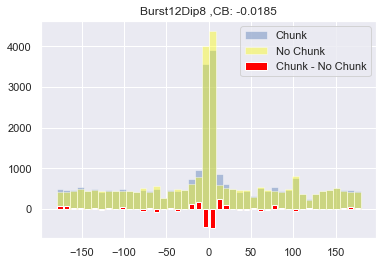

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip10/TestNoGo08/
80
80


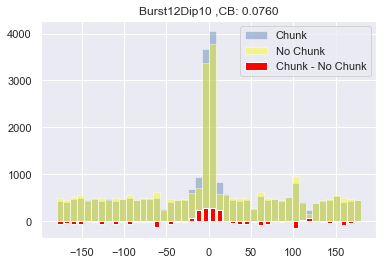

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip12/TestNoGo08/
80
80


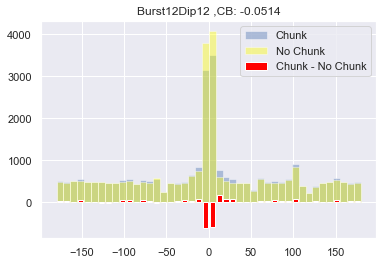

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip14/TestNoGo08/
80
80


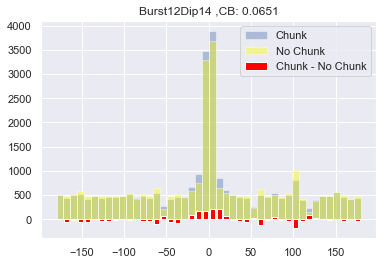

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip16/TestNoGo08/
80
80


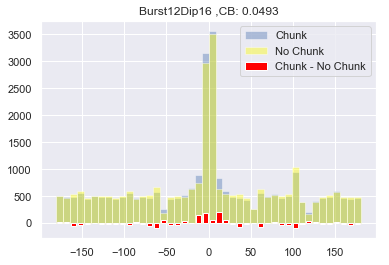

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip4/TestNoGo08/
80
80


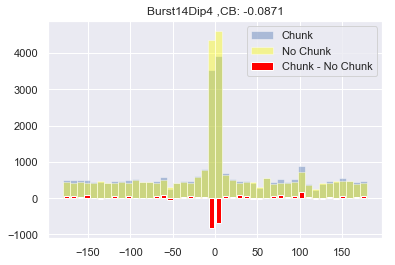

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/TestNoGo08/
80
80


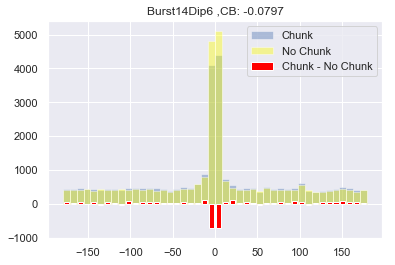

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip8/TestNoGo08/
80
80


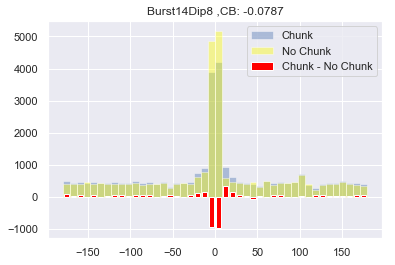

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/TestNoGo08/
80
80


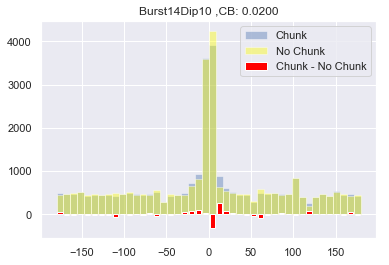

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip12/TestNoGo08/
80
80


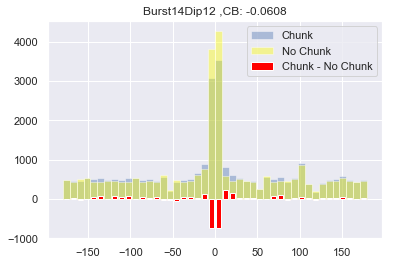

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip14/TestNoGo08/
80
80


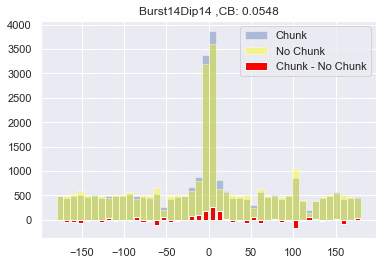

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip16/TestNoGo08/
80
80


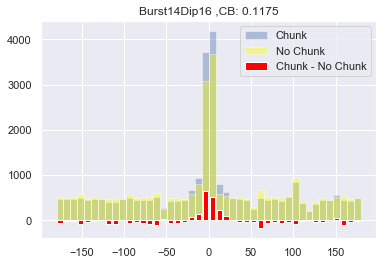

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo08/
80
80


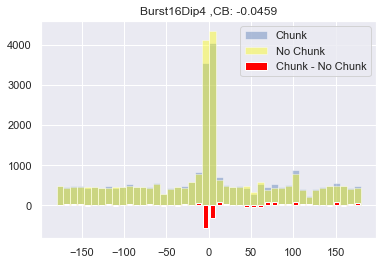

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo08/
80
80


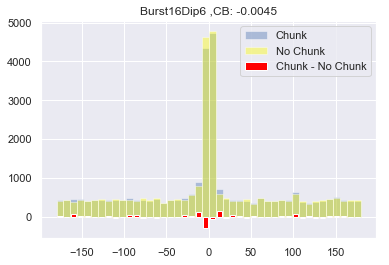

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo08/
80
80


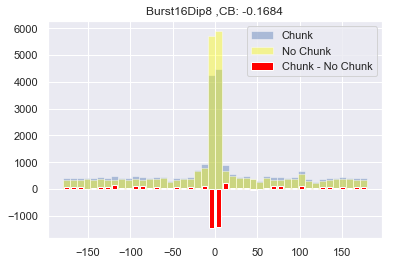

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo08/
80
80


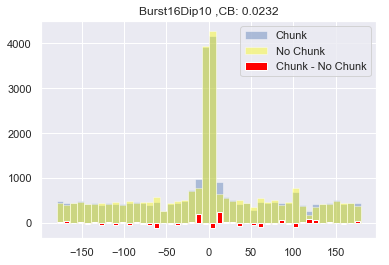

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo08/
80
80


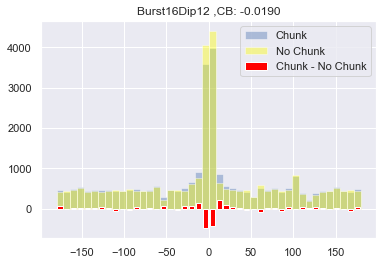

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo08/
80
80


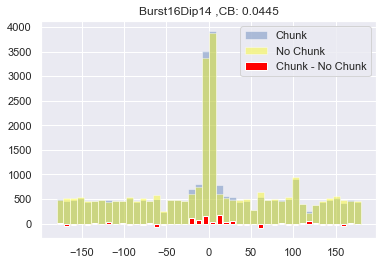

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo08/
80
80


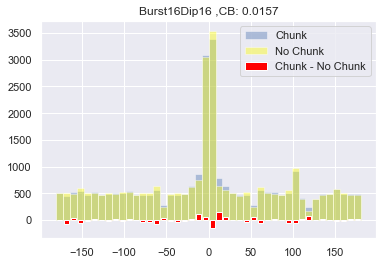

In [66]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


# Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# BurstName =["4", "6", "8", "10", "12", "14", "16"]
# DipName = ["4", "6", "8", "10", "12", "14", "16"]

Burst = [1.2, 1.4, 1.6]
BurstName =["12", "14", "16"]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
DipName = ["4", "6", "8", "10", "12", "14", "16"]


#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "3"
nogo = "TestNoGo08/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo08"

# chunking_benefit=[]
# chunk_ABE = []
# nochunk_ABE = []
# burstdip = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip4/TestNoGo125/
80
80


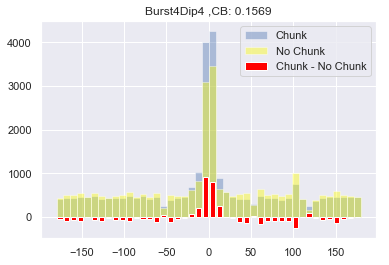

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip6/TestNoGo125/
80
80


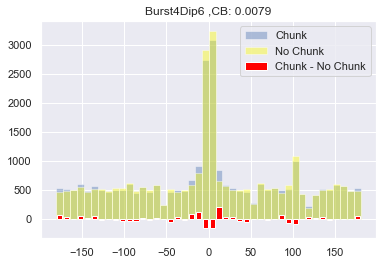

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip8/TestNoGo125/
80
80


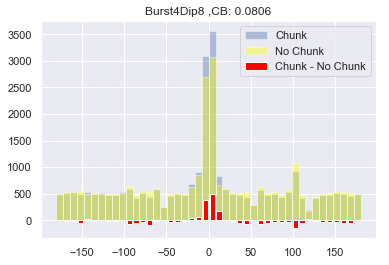

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip10/TestNoGo125/
80
80


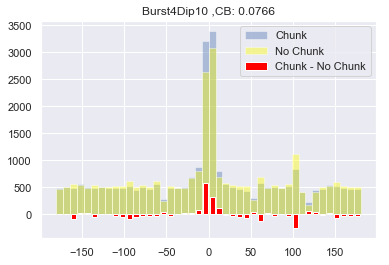

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip12/TestNoGo125/
80
80


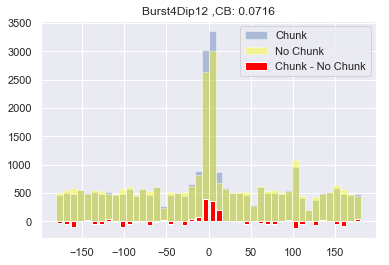

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip14/TestNoGo125/
80
80


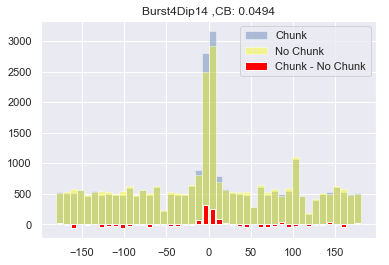

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/TestNoGo125/
80
80


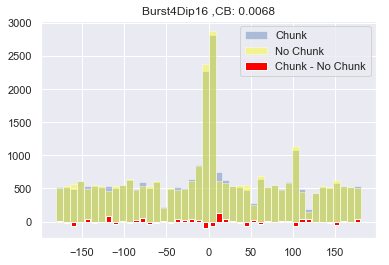

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip4/TestNoGo125/
80
80


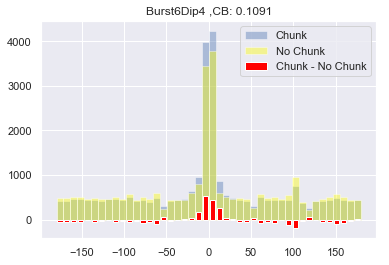

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/TestNoGo125/
80
80


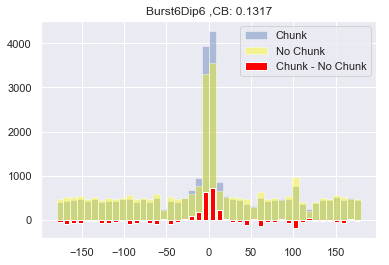

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip8/TestNoGo125/
80
80


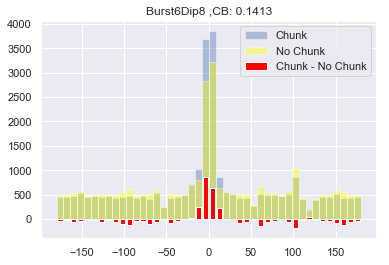

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip10/TestNoGo125/
80
80


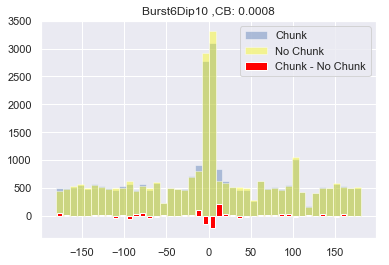

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip12/TestNoGo125/
80
80


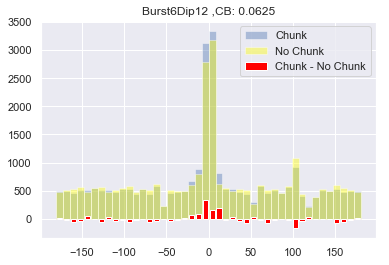

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip14/TestNoGo125/
80
80


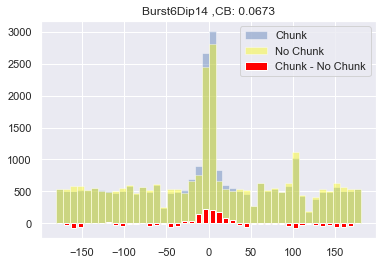

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/TestNoGo125/
80
80


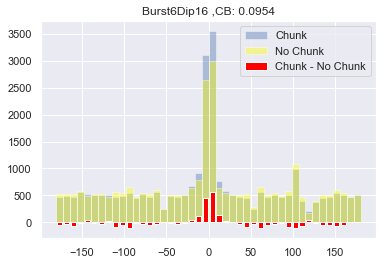

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip4/TestNoGo125/
80
80


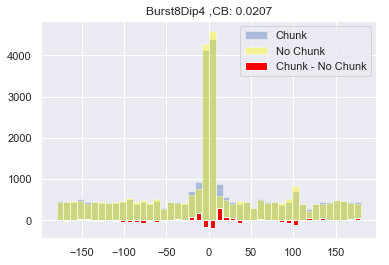

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip6/TestNoGo125/
80
80


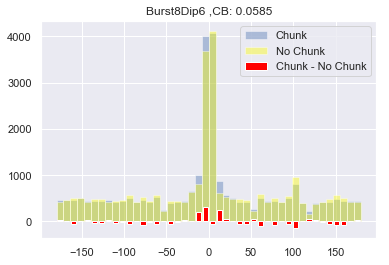

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip8/TestNoGo125/
80
80


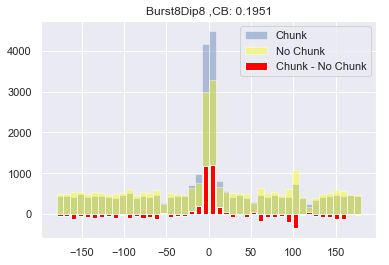

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip10/TestNoGo125/
80
80


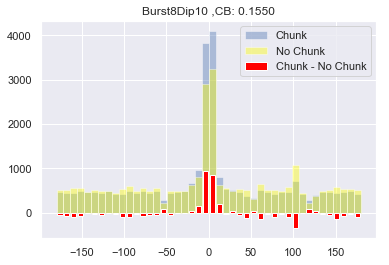

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip12/TestNoGo125/
80
80


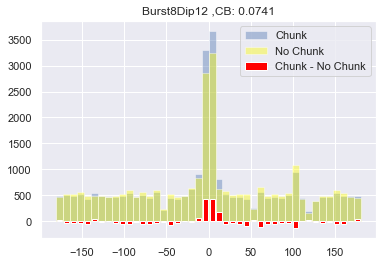

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip14/TestNoGo125/
80
80


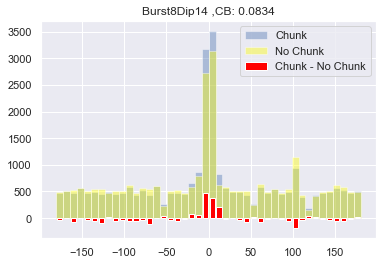

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip16/TestNoGo125/
80
80


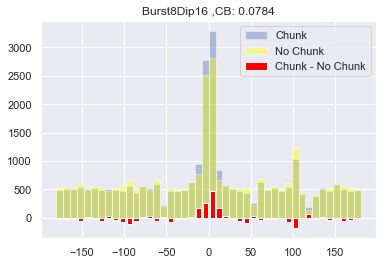

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip4/TestNoGo125/
80
80


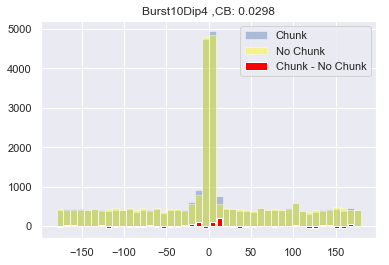

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/TestNoGo125/
80
80


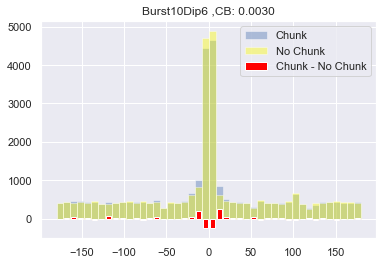

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip8/TestNoGo125/
80
80


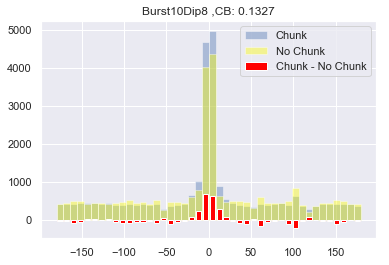

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/
80
80


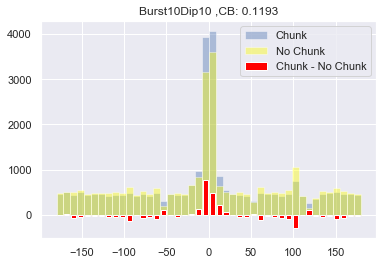

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip12/TestNoGo125/
80
80


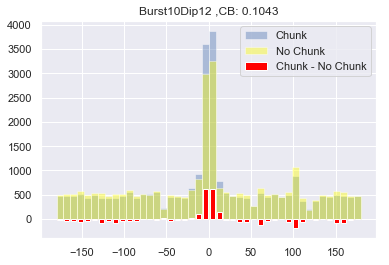

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip14/TestNoGo125/
80
80


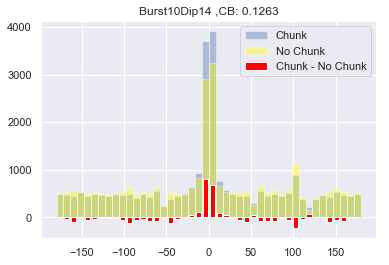

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/TestNoGo125/
80
80


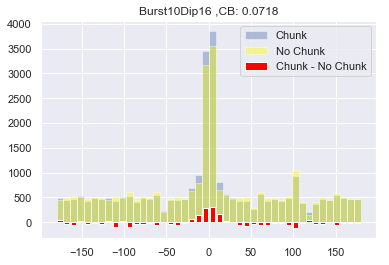

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip4/TestNoGo125/
80
80


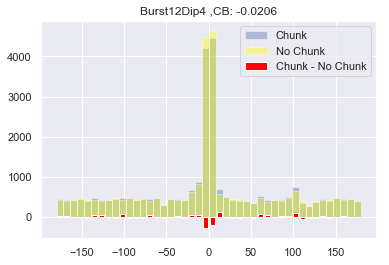

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo125/
80
80


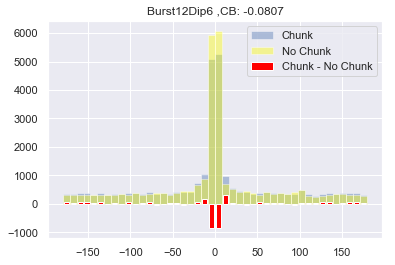

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo125/
80
80


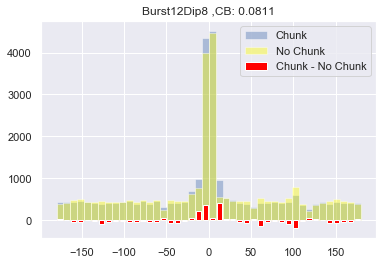

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip10/TestNoGo125/
80
80


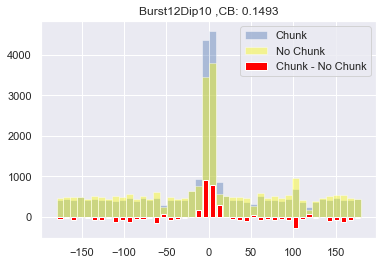

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip12/TestNoGo125/
80
80


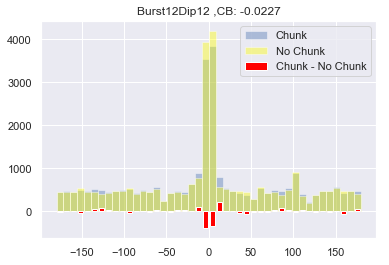

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip14/TestNoGo125/
80
80


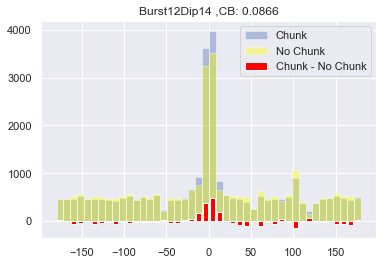

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip16/TestNoGo125/
80
80


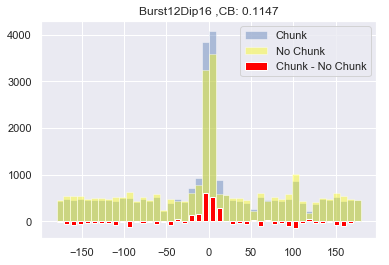

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip4/TestNoGo125/
80
80


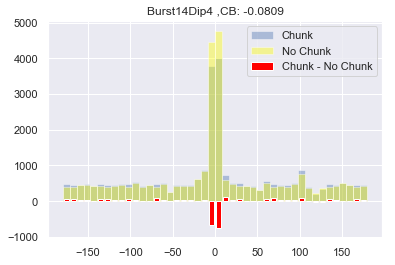

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/TestNoGo125/
80
80


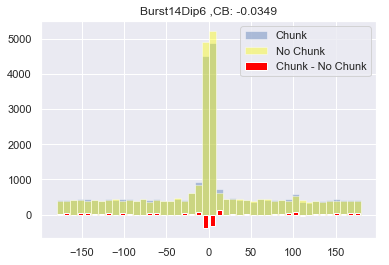

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip8/TestNoGo125/
80
80


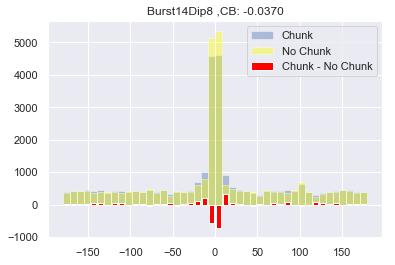

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/TestNoGo125/
80
80


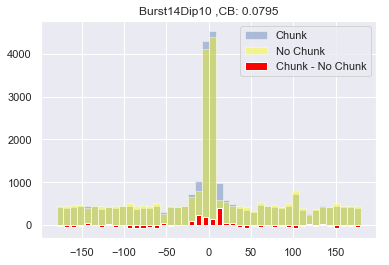

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip12/TestNoGo125/
80
80


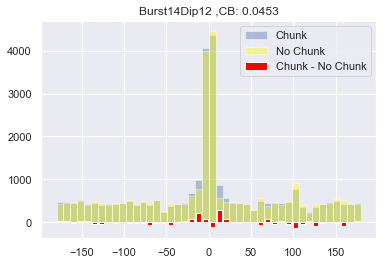

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip14/TestNoGo125/
80
80


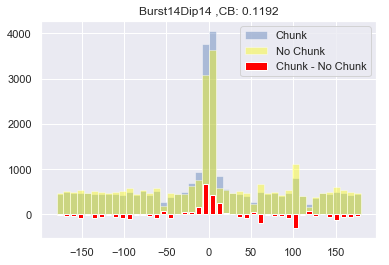

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip16/TestNoGo125/
80
80


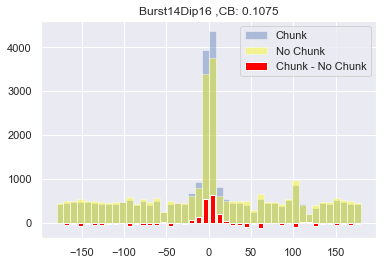

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo125/
80
80


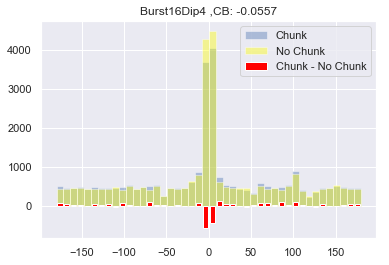

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo125/
80
80


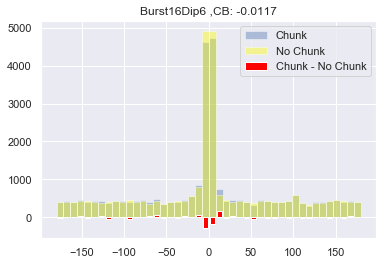

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo125/
80
80


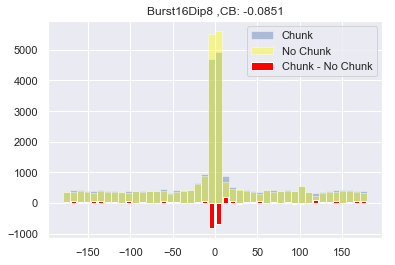

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo125/
80
80


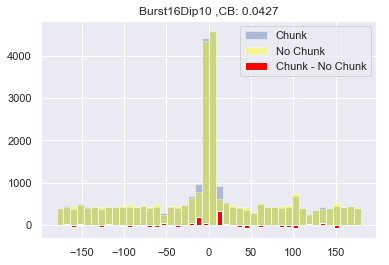

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo125/
80
80


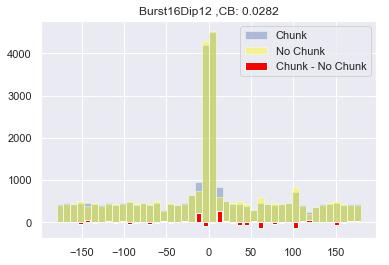

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo125/
80
80


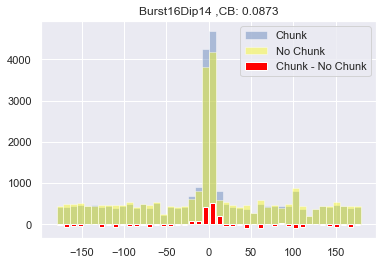

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo125/
80
80


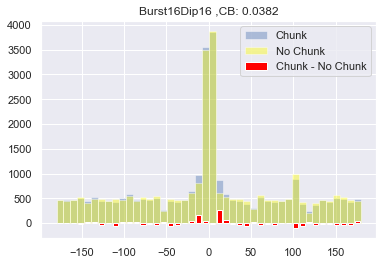

In [67]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["4", "6", "8", "10", "12", "14", "16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]


#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "3"
nogo = "TestNoGo125/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo125"

# chunking_benefit=[]
# chunk_ABE = []
# nochunk_ABE = []
# burstdip = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip4/TestNoGo16/
80
80


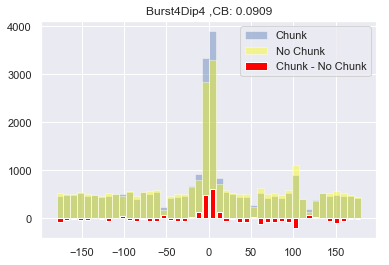

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip6/TestNoGo16/
80
80


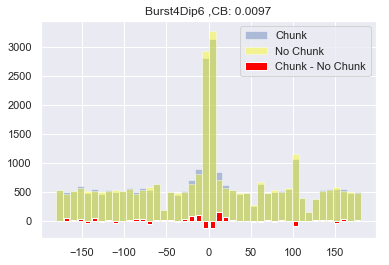

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip8/TestNoGo16/
80
80


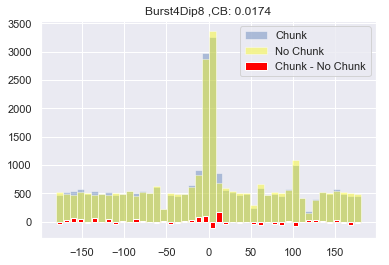

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip10/TestNoGo16/
80
80


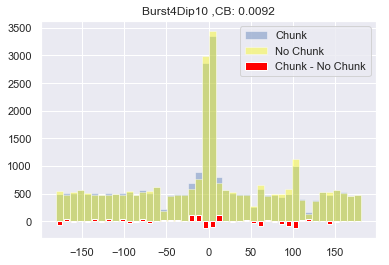

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip12/TestNoGo16/
80
80


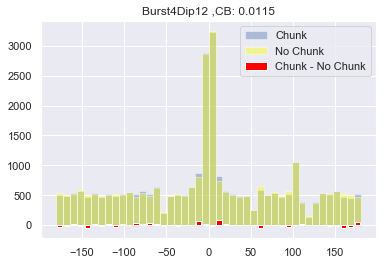

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip14/TestNoGo16/
80
80


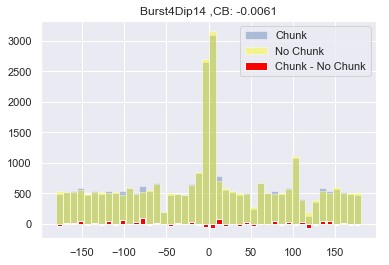

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/TestNoGo16/
80
80


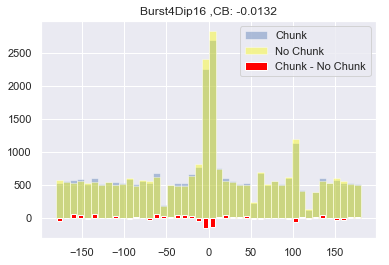

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip4/TestNoGo16/
80
80


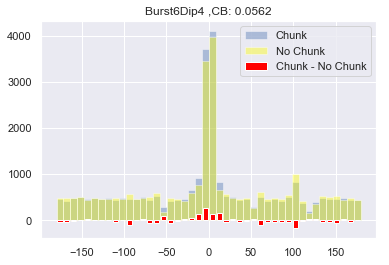

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/TestNoGo16/
80
80


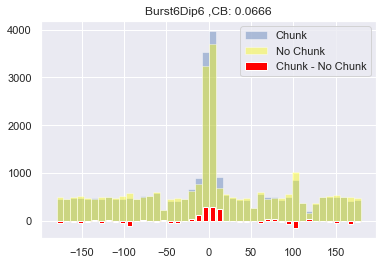

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip8/TestNoGo16/
80
80


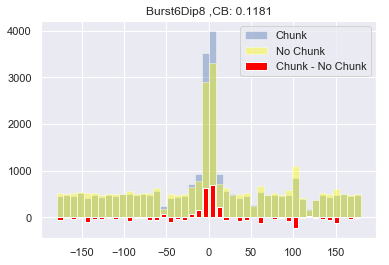

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip10/TestNoGo16/
80
80


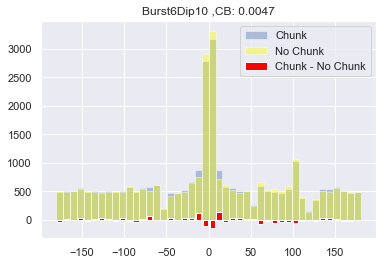

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip12/TestNoGo16/
80
80


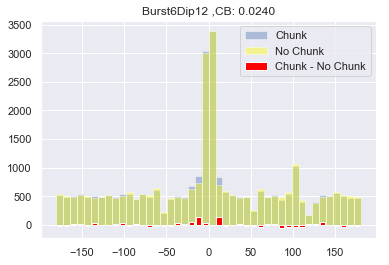

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip14/TestNoGo16/
80
80


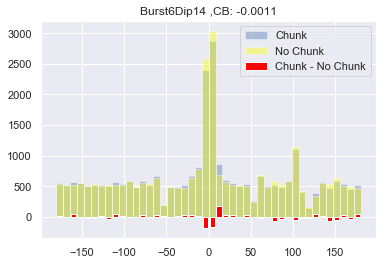

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/TestNoGo16/
80
80


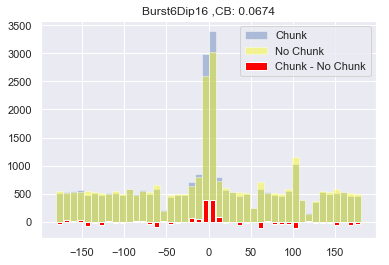

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip4/TestNoGo16/
80
80


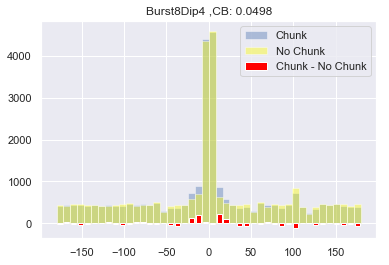

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip6/TestNoGo16/
80
80


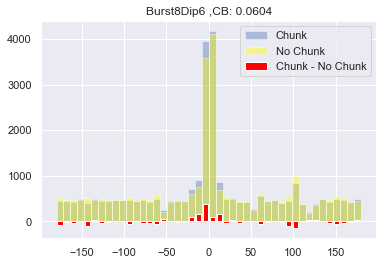

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip8/TestNoGo16/
80
80


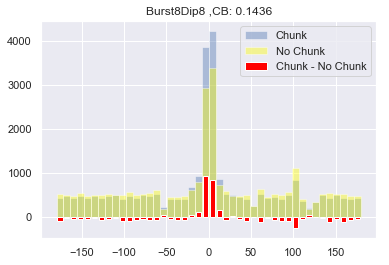

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip10/TestNoGo16/
80
80


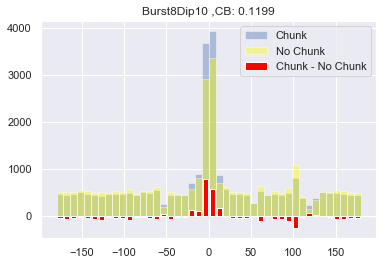

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip12/TestNoGo16/
80
80


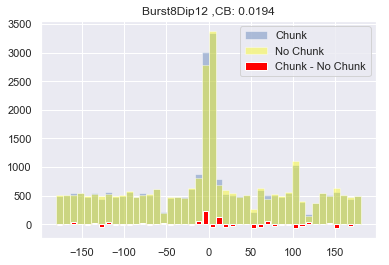

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip14/TestNoGo16/
80
80


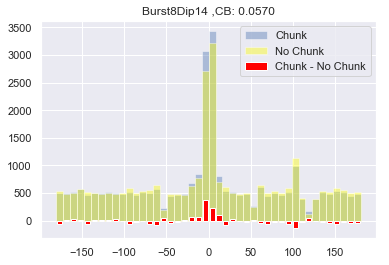

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip16/TestNoGo16/
80
80


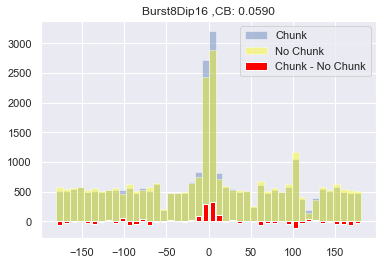

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip4/TestNoGo16/
80
80


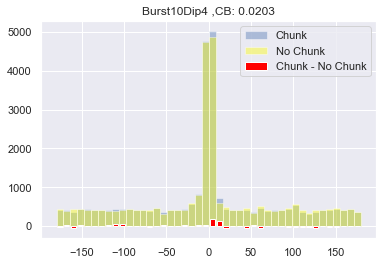

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/TestNoGo16/
80
80


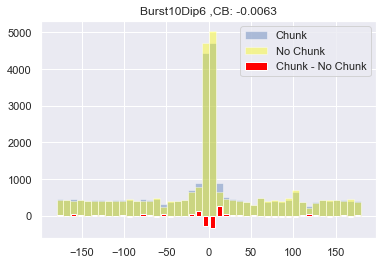

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip8/TestNoGo16/
80
80


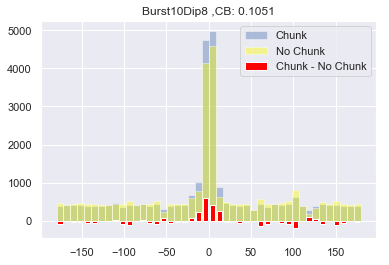

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo16/
80
80


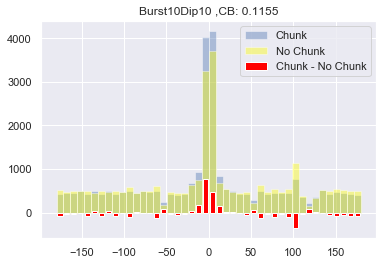

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip12/TestNoGo16/
80
80


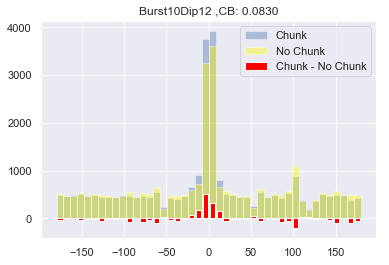

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip14/TestNoGo16/
80
80


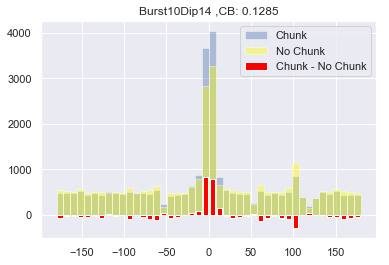

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/TestNoGo16/
80
80


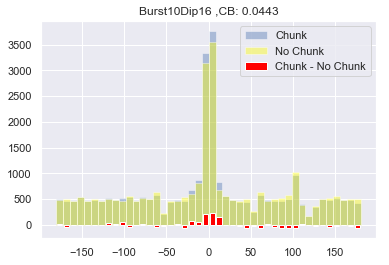

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip4/TestNoGo16/
80
80


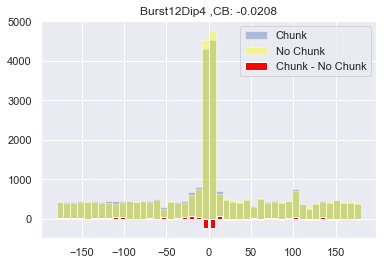

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo16/
80
80


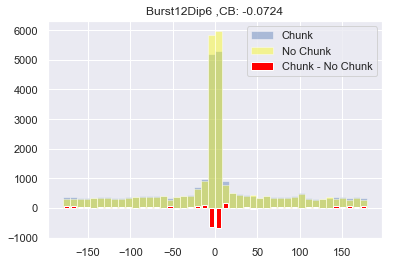

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo16/
80
80


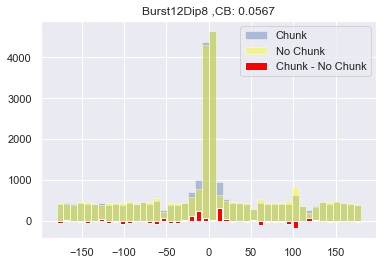

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip10/TestNoGo16/
80
80


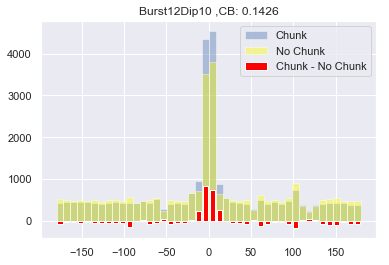

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip12/TestNoGo16/
80
80


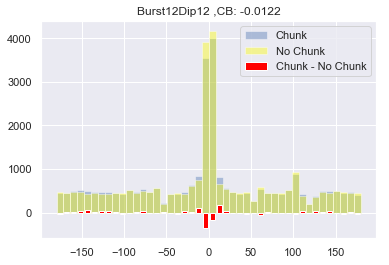

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip14/TestNoGo16/
80
80


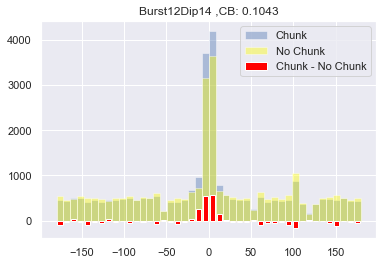

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip16/TestNoGo16/
80
80


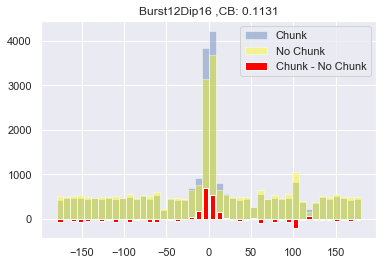

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip4/TestNoGo16/
80
80


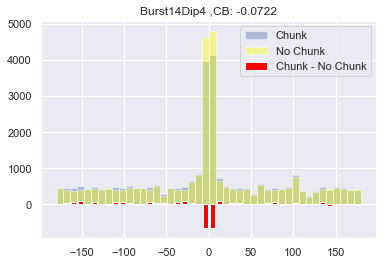

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/TestNoGo16/
80
80


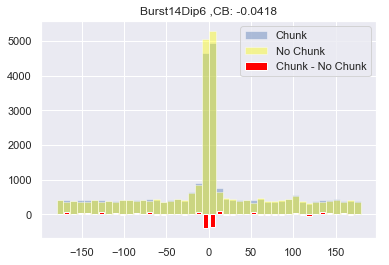

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip8/TestNoGo16/
80
80


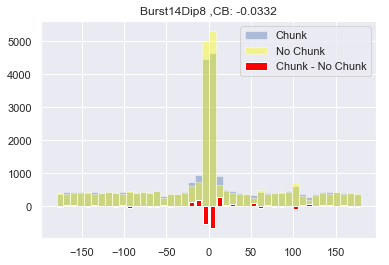

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/TestNoGo16/
80
80


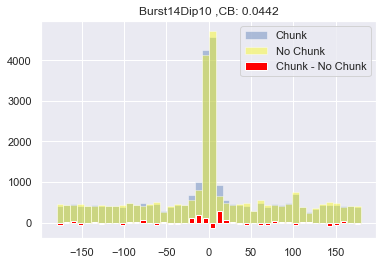

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip12/TestNoGo16/
80
80


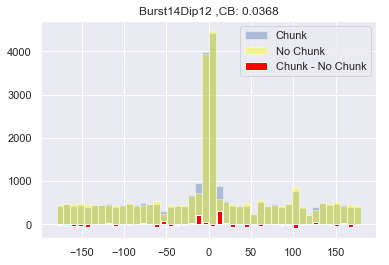

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip14/TestNoGo16/
80
80


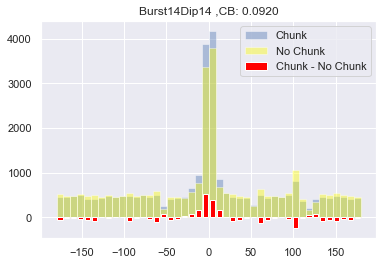

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip16/TestNoGo16/
80
80


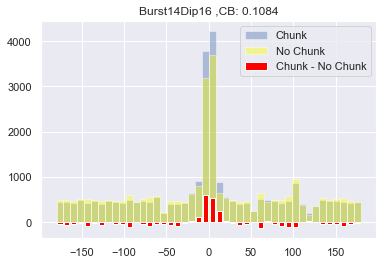

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo16/
80
80


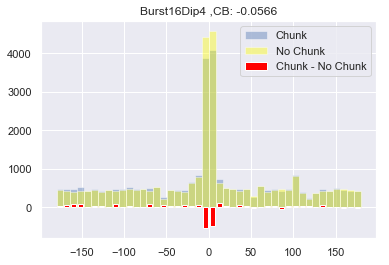

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo16/
80
80


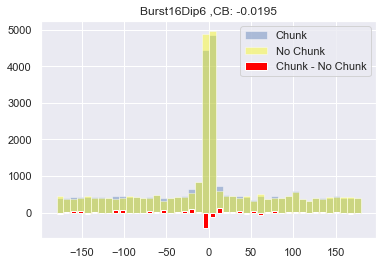

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo16/
80
80


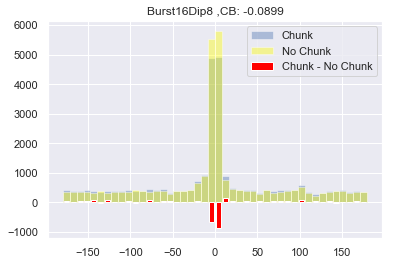

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo16/
80
80


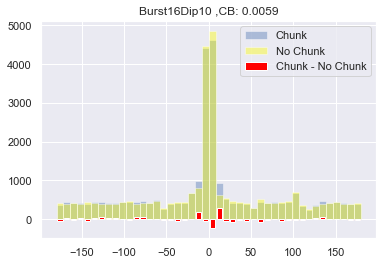

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo16/
80
80


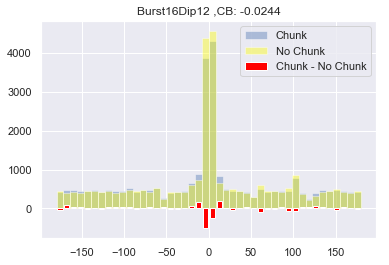

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo16/
80
80


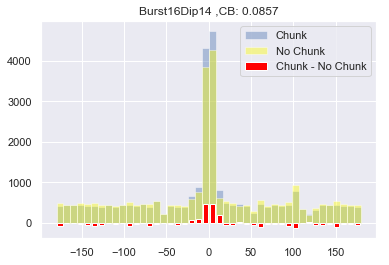

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo16/
80
80


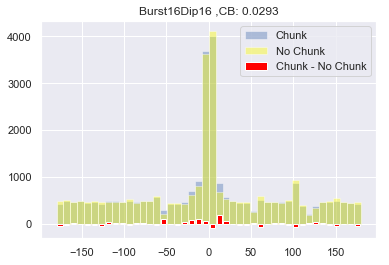

In [68]:


Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["4", "6", "8", "10", "12", "14", "16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "3"
nogo = "TestNoGo16/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo16"

chunking_benefit=[]
chunk_ABE = []
nochunk_ABE = []
burstdip = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

In [74]:
len(chunking_benefit)

10

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip4/TestNoGo08/
80
80


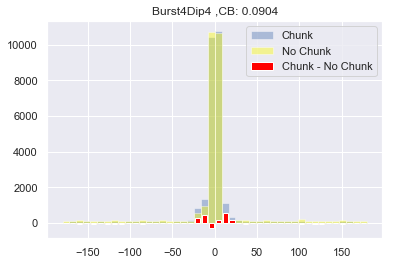

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip6/TestNoGo08/
80
80


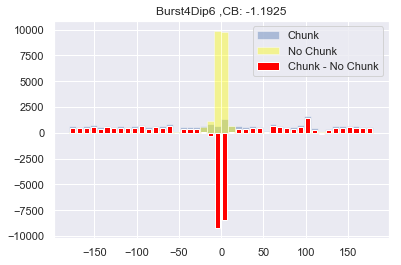

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip8/TestNoGo08/
80
80


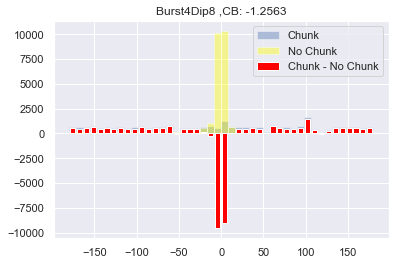

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip10/TestNoGo08/
80
80


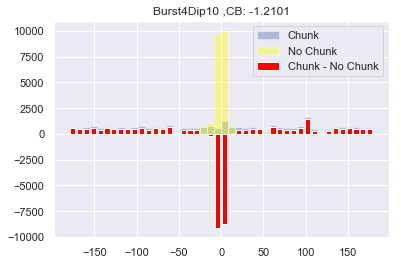

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip12/TestNoGo08/
80
80


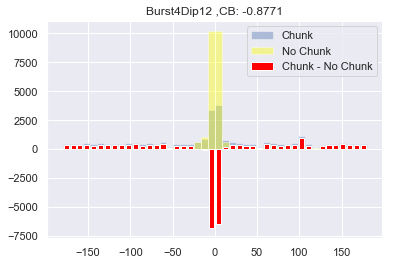

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip14/TestNoGo08/
80
80


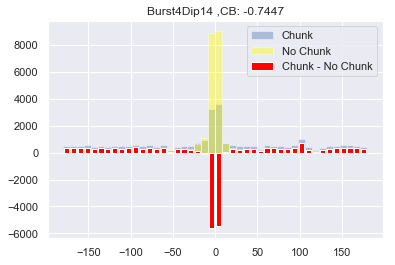

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/TestNoGo08/
80
80


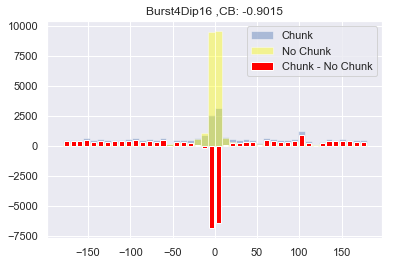

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip4/TestNoGo08/
80
80


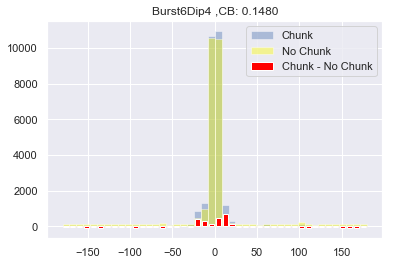

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip6/TestNoGo08/
80
80


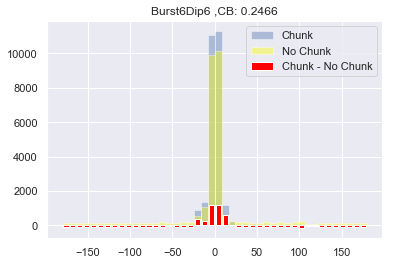

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip8/TestNoGo08/
80
80


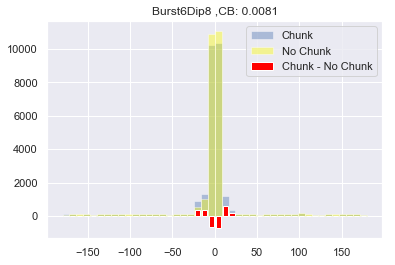

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip10/TestNoGo08/
80
80


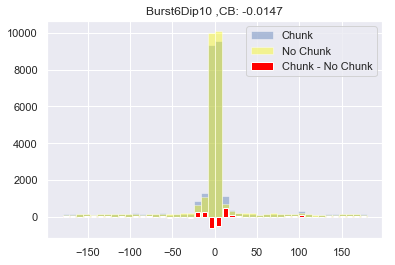

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip12/TestNoGo08/
80
80


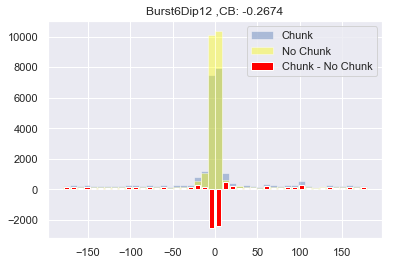

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip14/TestNoGo08/
80
80


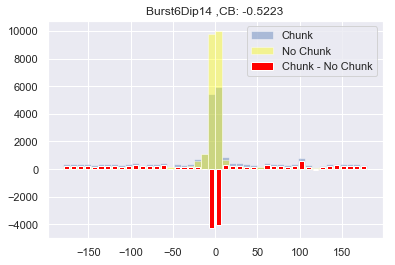

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst6/Dip16/TestNoGo08/
80
80


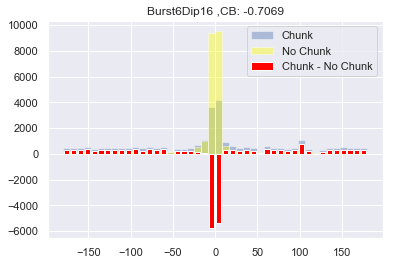

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip4/TestNoGo08/
80
80


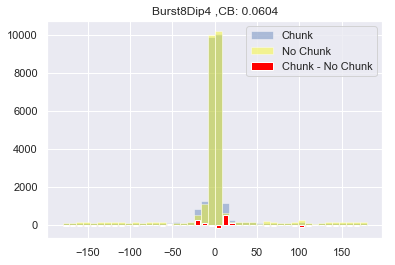

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip6/TestNoGo08/
80
80


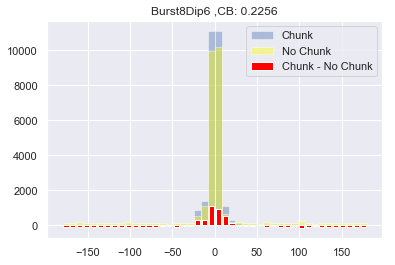

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip8/TestNoGo08/
80
80


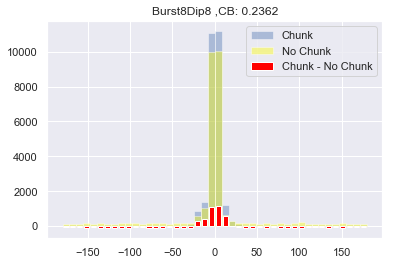

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip10/TestNoGo08/
80
80


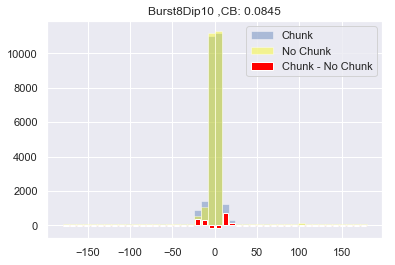

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip12/TestNoGo08/
80
80


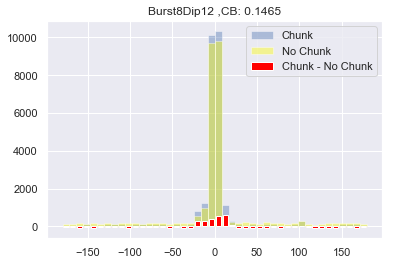

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip14/TestNoGo08/
80
80


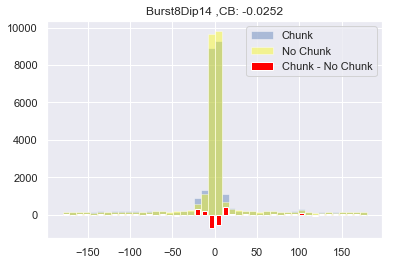

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip16/TestNoGo08/
80
80


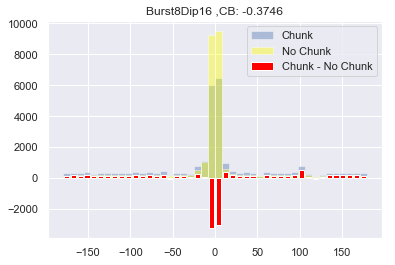

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip4/TestNoGo08/
80
80


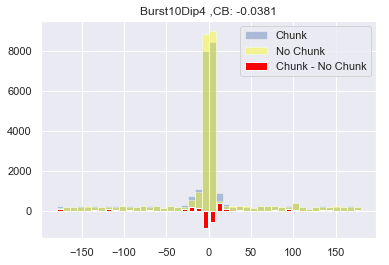

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/TestNoGo08/
80
80


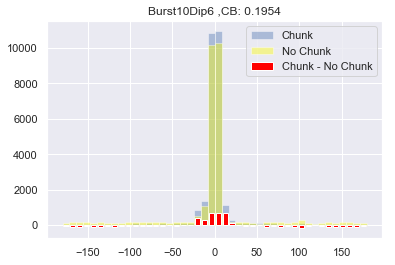

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip8/TestNoGo08/
80
80


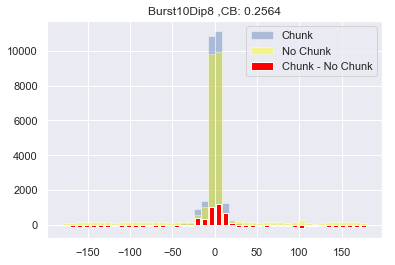

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo08/
80
80


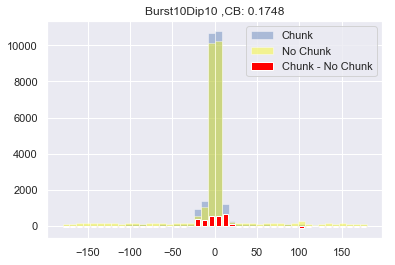

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip12/TestNoGo08/
80
80


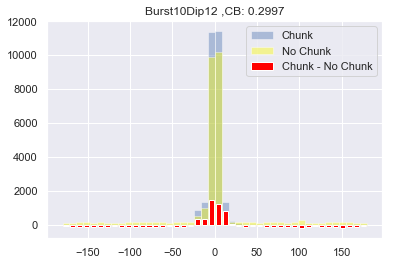

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip14/TestNoGo08/
80
80


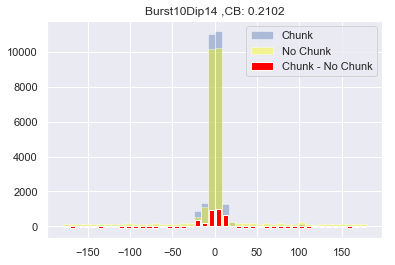

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/TestNoGo08/
80
80


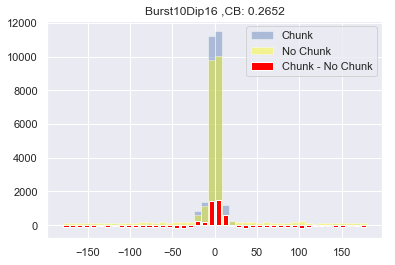

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip4/TestNoGo08/
80
80


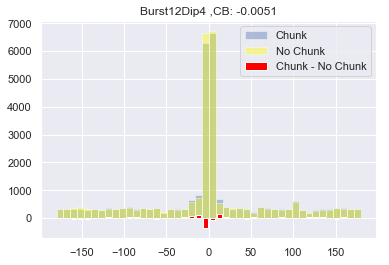

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo08/
80
80


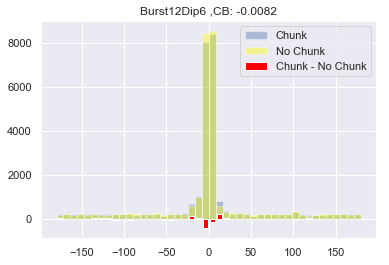

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo08/
80
80


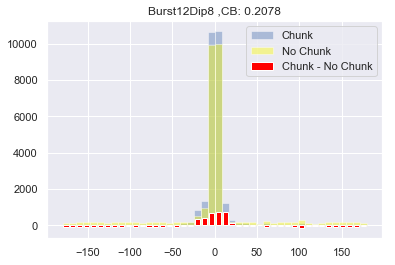

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip10/TestNoGo08/
80
80


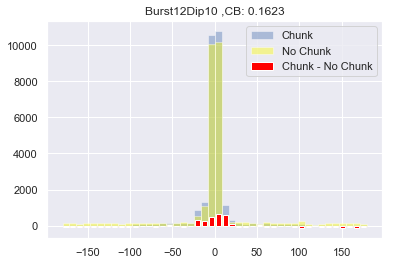

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip12/TestNoGo08/
80
80


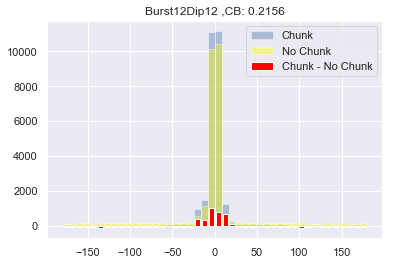

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip14/TestNoGo08/
80
80


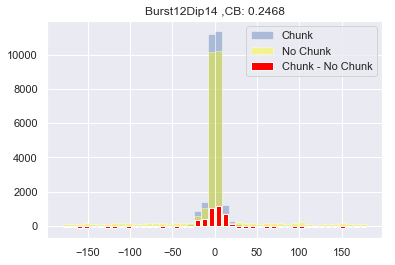

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip16/TestNoGo08/
80
80


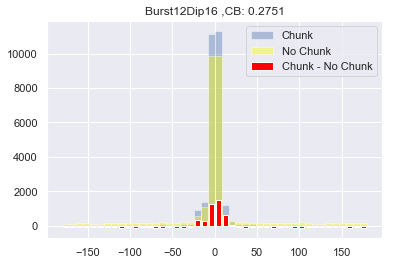

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip4/TestNoGo08/
80
80


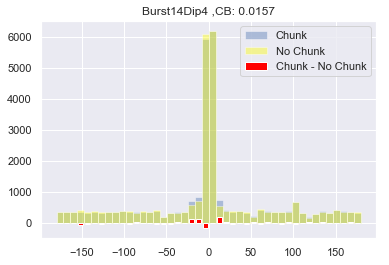

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip6/TestNoGo08/
80
80


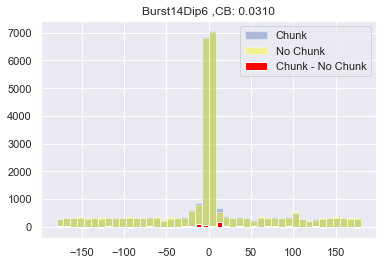

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip8/TestNoGo08/
80
80


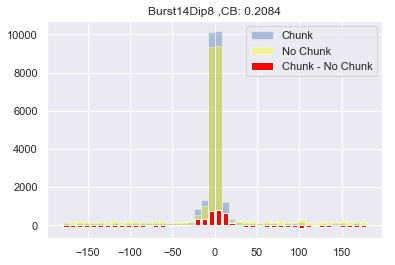

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/TestNoGo08/
80
80


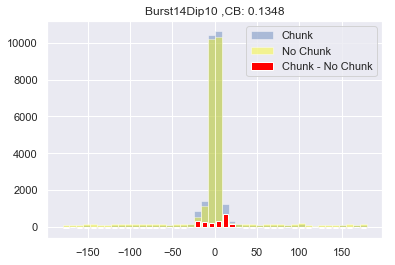

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip12/TestNoGo08/
80
80


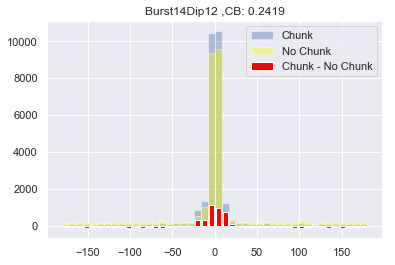

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip14/TestNoGo08/
80
80


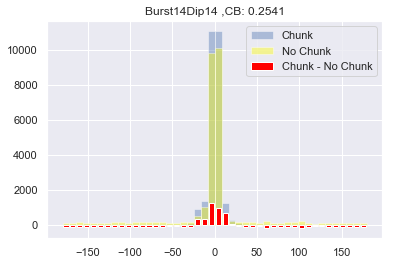

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip16/TestNoGo08/
80
80


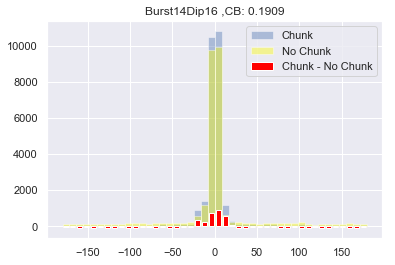

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/TestNoGo08/
80
80


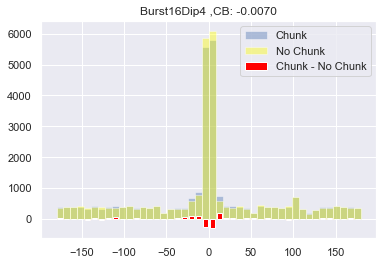

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip6/TestNoGo08/
80
80


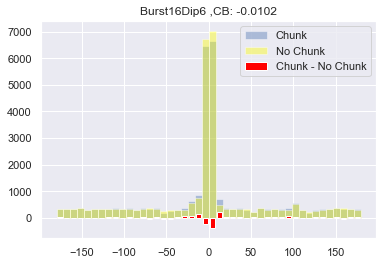

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip8/TestNoGo08/
80
80


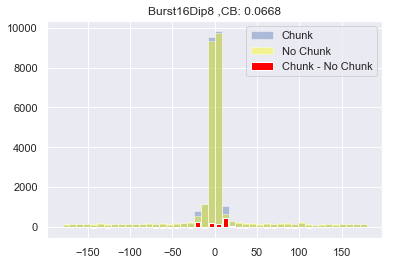

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip10/TestNoGo08/
80
80


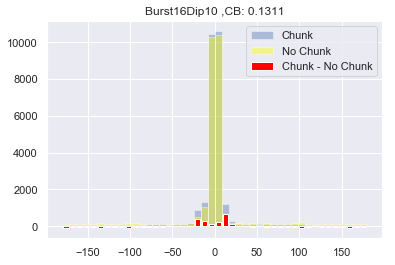

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip12/TestNoGo08/
80
80


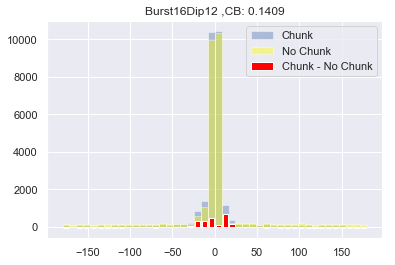

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip14/TestNoGo08/
80
80


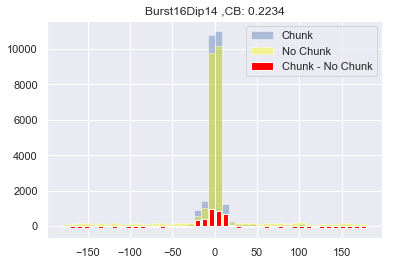

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/TestNoGo08/
80
80


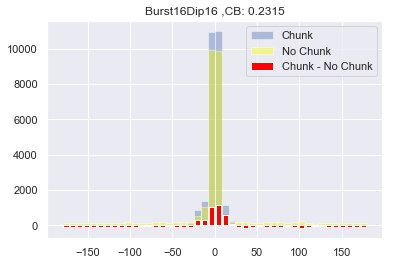

In [69]:



Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["4", "6", "8", "10", "12", "14", "16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "2"
nogo = "TestNoGo08/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo08"

chunking_benefit=[]
chunk_ABE = []
nochunk_ABE = []
burstdip = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip4/TestNoGo125/
80
80


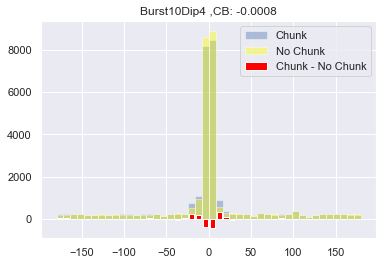

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip6/TestNoGo125/
80
80


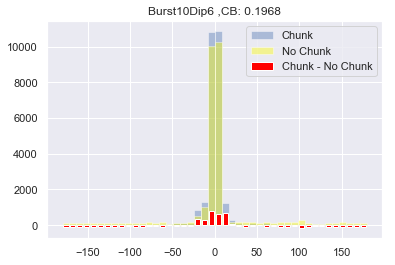

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip8/TestNoGo125/
80
80


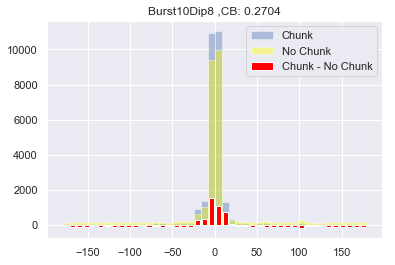

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/
80
80


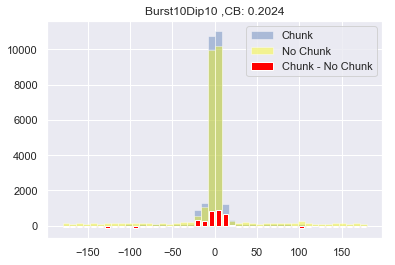

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip12/TestNoGo125/
80
80


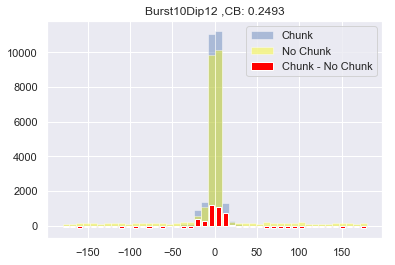

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip14/TestNoGo125/
80
80


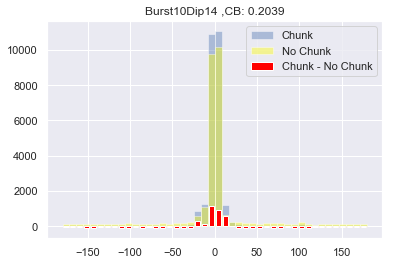

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip16/TestNoGo125/
80
80


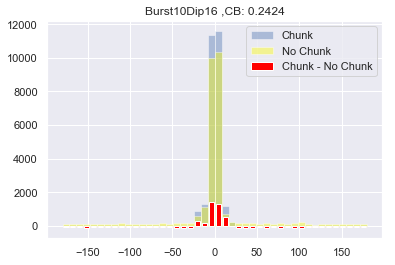

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip4/TestNoGo125/
80
80


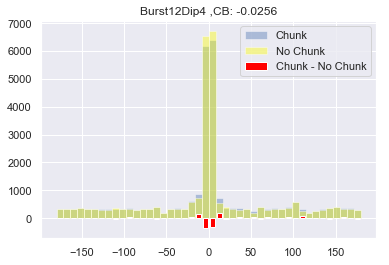

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo125/
80
80


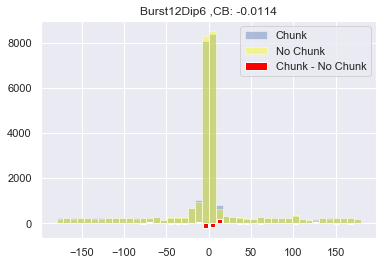

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo125/
80
80


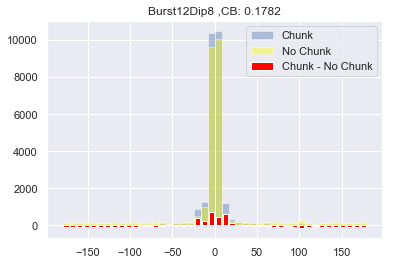

decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip10/TestNoGo125/
80


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [73]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["4", "6", "8", "10", "12", "14", "16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]

# Burst = [1.0, 1.2, 1.4, 1.6]
# Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# BurstName =["10", "12", "14", "16"]
# DipName = ["4", "6", "8", "10", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "2"
nogo = "TestNoGo125/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo125"

chunking_benefit=[]
chunk_ABE = []
nochunk_ABE = []
burstdip = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdip))
        #import pdb; pdb.set_trace()
        

In [76]:

# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["4", "6", "8", "10", "12", "14", "16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]


# Burst = [1.0, 1.2, 1.4, 1.6]
# Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# BurstName =["10", "12", "14", "16"]
# DipName = ["4", "6", "8", "10", "12", "14", "16"]


#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "2"
nogo = "TestNoGo16/" #"TestNoGo125/", "TestNoGo16/"
savefile_append = "_trace01_nogo16"

chunking_benefit=[]
chunk_ABE = []
nochunk_ABE = []
burstdip = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain+nogo
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        
        chunking_benefit.append(CB)  
        chunk_ABE.append(total_mean_chunk)
        nochunk_ABE.append(total_mean_nochunk)
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        
        np.save("sir"+task+"_chunking_benefit"+savefile_append+".npy",np.array(chunking_benefit))
        np.save("sir"+task+"_chunk_ABE"+savefile_append+".npy",np.array(chunk_ABE))
        np.save("sir"+task+"_nochunk_ABE"+savefile_append+".npy",np.array(nochunk_ABE))
        np.save("sir"+task+"_burstdip"+savefile_append+".npy", np.array(burstdi===kkkkkkkkkkkkkp))
        #import pdb; pdb.set_trace()//..

SyntaxError: invalid syntax (<ipython-input-76-4f04ea3e16c2>, line 51)

In [ ]:
;d
[[[]]]